In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns 

In [2]:
df = pd.read_csv('ovo.csv')
df.info()
df.head(10)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 83182 entries, 0 to 83181
Data columns (total 5 columns):
 #   Column         Non-Null Count  Dtype 
---  ------         --------------  ----- 
 0   Unnamed: 0     83182 non-null  int64 
 1   created_at     83182 non-null  object
 2   score          83182 non-null  int64 
 3   content        83182 non-null  object
 4   thumbsUpCount  83182 non-null  int64 
dtypes: int64(3), object(2)
memory usage: 3.2+ MB


,Unnamed: 0,created_at,score,content,thumbsUpCount
0,0,2025-02-07 12:46:44,3,Tidak bisa upgrade ke premier dikarenakan siny...,7
1,1,2025-01-15 09:10:09,1,"Aplikasi paling gak jelas, biaya segala macemn...",151
2,2,2024-12-16 00:20:17,1,"Sangat mengecewakan, pengiriman lambat, potong...",469
3,3,2025-02-07 23:38:13,1,Ovo semakin lama biaya transaksi semakin mahal...,2
4,4,2024-12-02 13:48:18,1,Sebelum daftar grab driver akun saya sudah say...,238
5,5,2025-01-27 13:23:08,5,"Ini aplikasi semakin lama semakin menyebalkan,...",268
6,6,2025-01-12 15:24:29,1,"Aplikasi paling ribet. Pertama, Verifikasi ema...",126
7,7,2025-01-04 16:55:05,1,Ini aplikasi bukan mempermudah malah bikin mas...,303
8,8,2025-01-14 11:32:55,1,"Saya sdh top-up , tp dana tidak masuk.. Saya t...",211
9,9,2024-11-23 23:41:35,1,"saya beri rating 1, karena apk nya sangat sang...",202


In [3]:
print("shape of the dataset: ", df.shape)
print("\nDatatype of the columns: ")
df.info()

shape of the dataset:  (83182, 5)

Datatype of the columns: 
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 83182 entries, 0 to 83181
Data columns (total 5 columns):
 #   Column         Non-Null Count  Dtype 
---  ------         --------------  ----- 
 0   Unnamed: 0     83182 non-null  int64 
 1   created_at     83182 non-null  object
 2   score          83182 non-null  int64 
 3   content        83182 non-null  object
 4   thumbsUpCount  83182 non-null  int64 
dtypes: int64(3), object(2)
memory usage: 3.2+ MB


In [4]:
print("\nMissing values in each columns: ")
print(df.isnull().sum())


Missing values in each columns: 
Unnamed: 0       0
created_at       0
score            0
content          0
thumbsUpCount    0
dtype: int64


In [5]:
print("\nUnique values in each columns: ")
print(df.nunique())


Unique values in each columns: 
Unnamed: 0       83182
created_at       83125
score                5
content          82713
thumbsUpCount      287
dtype: int64


In [6]:
#Desriptive Statistics
print("\nDescriptive Statistics of the dataset: ")
print(df.describe())


Descriptive Statistics of the dataset: 
         Unnamed: 0         score  thumbsUpCount
count  83182.000000  83182.000000   83182.000000
mean   41590.500000      2.325515       2.009786
std    24012.719383      1.700360      24.338824
min        0.000000      1.000000       0.000000
25%    20795.250000      1.000000       0.000000
50%    41590.500000      1.000000       0.000000
75%    62385.750000      4.000000       0.000000
max    83181.000000      5.000000    2282.000000


In [3]:
# Hapus kolom indeks yang tidak diperlukan
import pandas as pd 
import numpy as np
import seaborn as sns
df = pd.read_csv('ovo.csv')
df = df.drop(columns=['Unnamed: 0'])

# Konversi kolom waktu ke format datetime
df['created_at'] = pd.to_datetime(df['created_at'])

# Cek dan hapus duplikasi berdasarkan konten ulasan (opsional namun disarankan)
df = df.drop_duplicates(subset=['content'])

print(df.info())

<class 'pandas.core.frame.DataFrame'>
Index: 82713 entries, 0 to 83181
Data columns (total 4 columns):
 #   Column         Non-Null Count  Dtype         
---  ------         --------------  -----         
 0   created_at     82713 non-null  datetime64[ns]
 1   score          82713 non-null  int64         
 2   content        82713 non-null  object        
 3   thumbsUpCount  82713 non-null  int64         
dtypes: datetime64[ns](1), int64(2), object(1)
memory usage: 3.2+ MB
None


/var/folders/n4/5f0j234x5m79703ndtqxkcr00000gn/T/ipykernel_2047/1048772677.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x='score', palette='viridis')


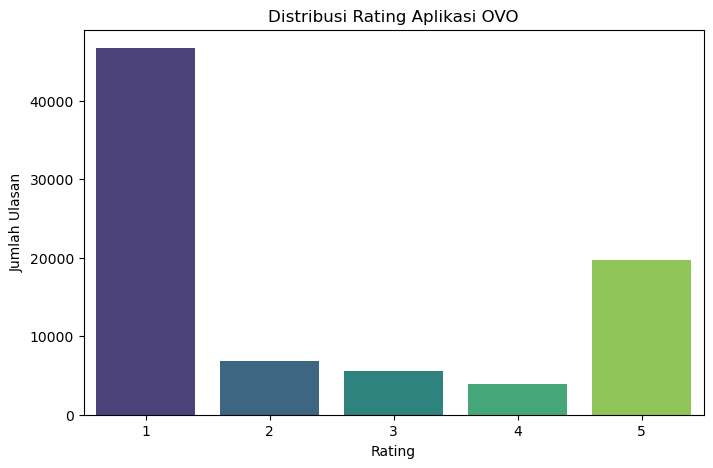

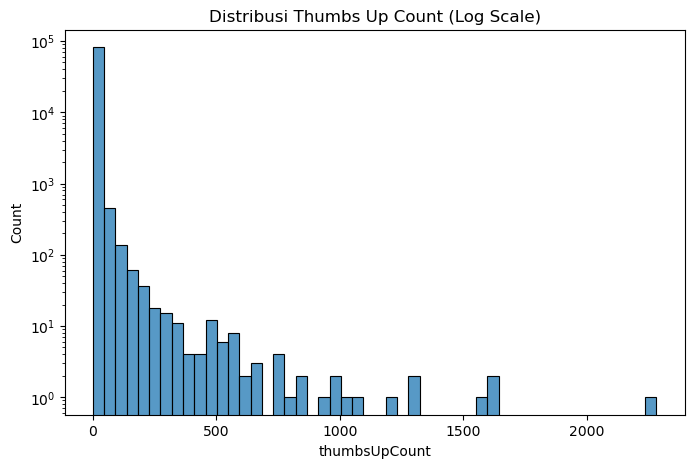

In [5]:
#Analisis Data - Univariate Analysis
import pandas as pd 
import numpy as np 
import seaborn as sns 
import matplotlib.pyplot as plt

# Distribusi Rating (Score)
plt.figure(figsize=(8, 5))
sns.countplot(data=df, x='score', palette='viridis')
plt.title('Distribusi Rating Aplikasi OVO')
plt.xlabel('Rating')
plt.ylabel('Jumlah Ulasan')
plt.show()

# Distribusi Thumbs Up (karena rentangnya 0-2282, kita gunakan skala logaritmik jika perlu)
plt.figure(figsize=(8, 5))
sns.histplot(df['thumbsUpCount'], bins=50, kde=False)
plt.yscale('log')
plt.title('Distribusi Thumbs Up Count (Log Scale)')
plt.show()

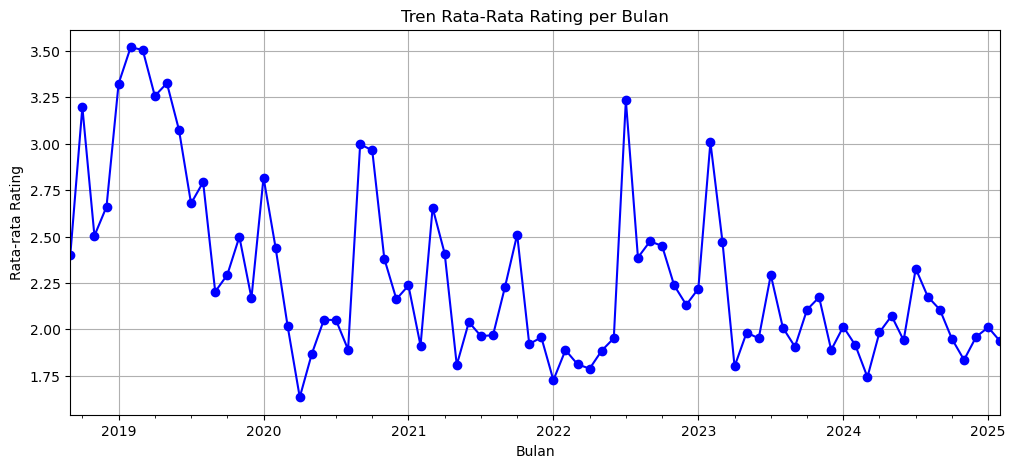

In [6]:
#Analisis Trend Waktu 
# Ekstrak Tahun dan Bulan untuk agregasi
df['year_month'] = df['created_at'].dt.to_period('M')

# Agregasi rata-rata score per bulan
tren_rating = df.groupby('year_month')['score'].mean()

plt.figure(figsize=(12, 5))
tren_rating.plot(marker='o', color='b')
plt.title('Tren Rata-Rata Rating per Bulan')
plt.xlabel('Bulan')
plt.ylabel('Rata-rata Rating')
plt.grid(True)
plt.show()

/var/folders/n4/5f0j234x5m79703ndtqxkcr00000gn/T/ipykernel_2047/456337306.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='score', y='review_length', palette='coolwarm')


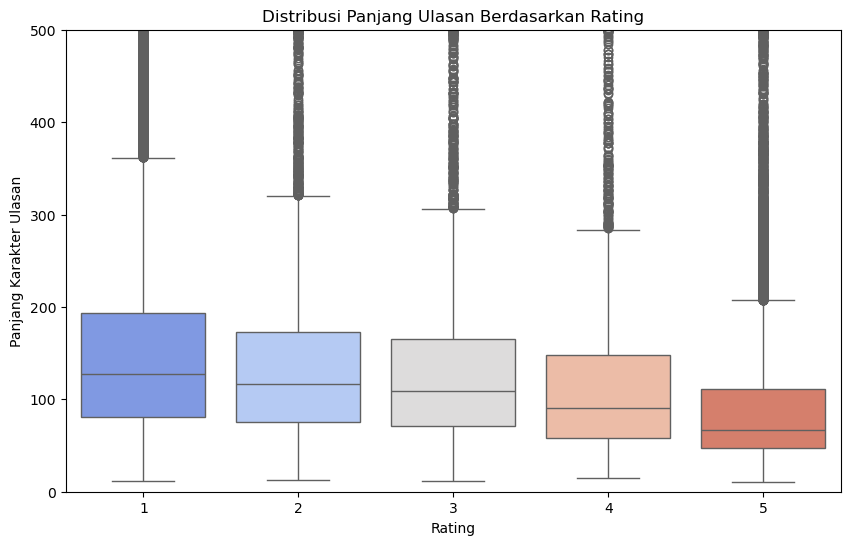

In [8]:
#Text Analysis
# Menghitung panjang karakter dari masing-masing ulasan
df['review_length'] = df['content'].apply(lambda x: len(str(x)))

# Visualisasi hubungan antara rating dan panjang ulasan
plt.figure(figsize=(10, 6))
sns.boxplot(data=df, x='score', y='review_length', palette='coolwarm')
plt.title('Distribusi Panjang Ulasan Berdasarkan Rating')
plt.xlabel('Rating')
plt.ylabel('Panjang Karakter Ulasan')
# Membatasi sumbu Y jika terdapat outlier ekstrem (misal ulasan ribuan karakter)
plt.ylim(0, 500) 
plt.show()

/var/folders/n4/5f0j234x5m79703ndtqxkcr00000gn/T/ipykernel_2047/2022614780.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df, x='score', y='thumbsUpCount', estimator=np.mean, palette='Reds_r')


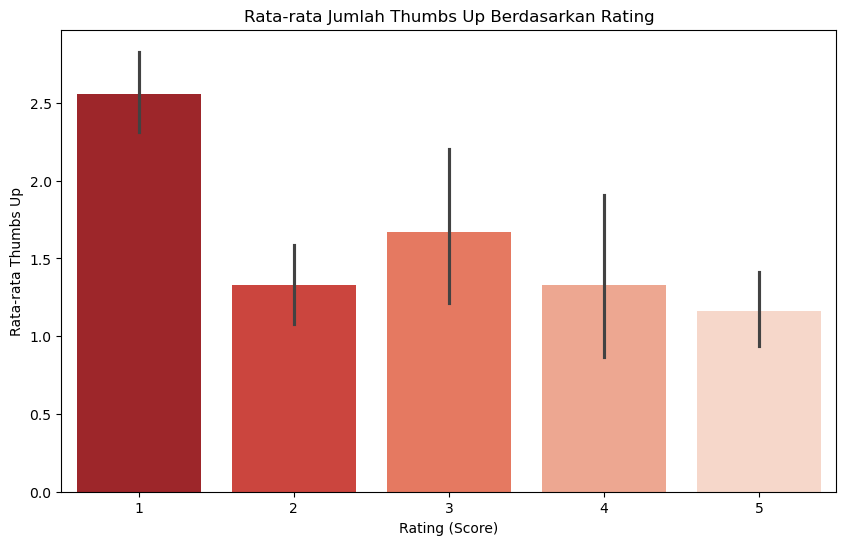

In [10]:
#Analisis Interaksi Pengguna 
plt.figure(figsize=(10, 6))
# Menggunakan barplot untuk melihat rata-rata thumbsUpCount di setiap rating
sns.barplot(data=df, x='score', y='thumbsUpCount', estimator=np.mean, palette='Reds_r')
plt.title('Rata-rata Jumlah Thumbs Up Berdasarkan Rating')
plt.xlabel('Rating (Score)')
plt.ylabel('Rata-rata Thumbs Up')
plt.show()

/var/folders/n4/5f0j234x5m79703ndtqxkcr00000gn/T/ipykernel_2047/153469339.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x='hour_of_day', palette='cividis')


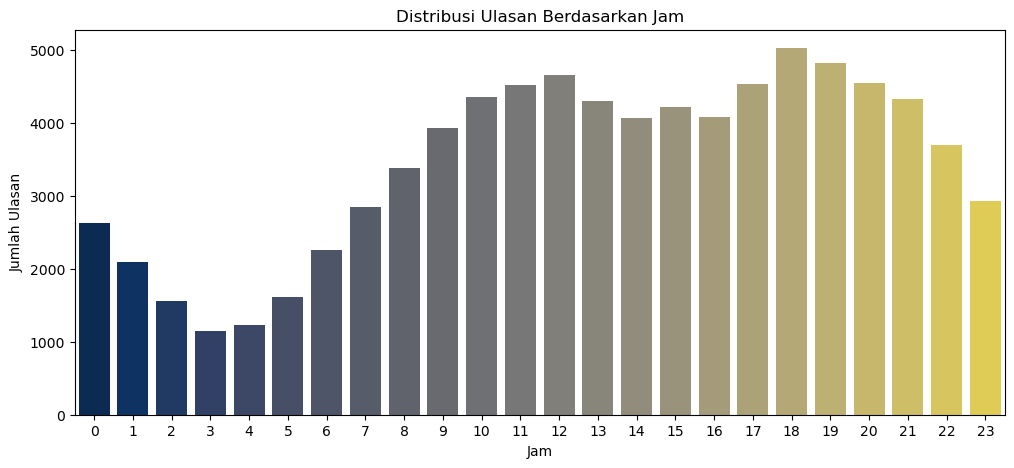

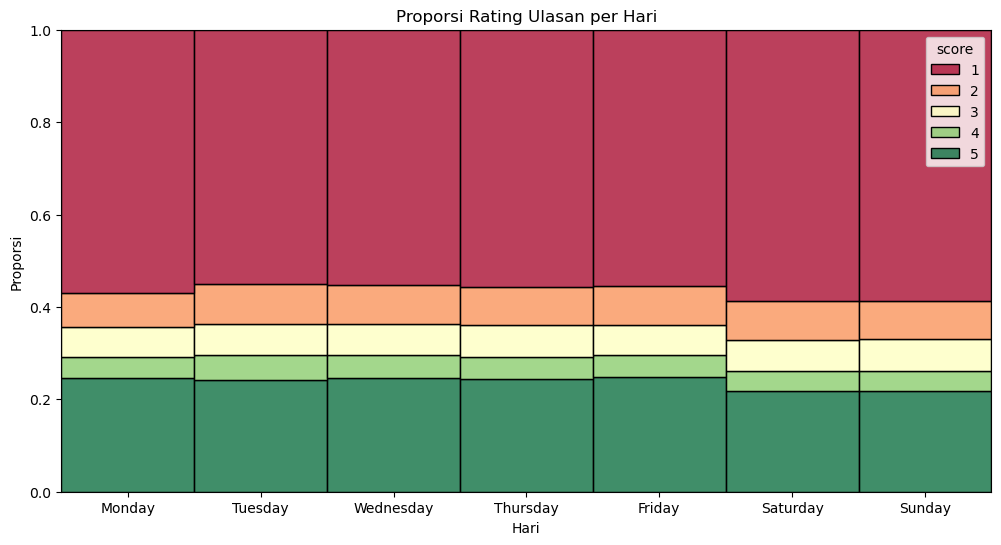

In [11]:
#Pola Waktu Interaksi Pengguna
# Mengekstrak nama hari dan jam dari kolom created_at
df['day_of_week'] = df['created_at'].dt.day_name()
df['hour_of_day'] = df['created_at'].dt.hour

# Mengurutkan hari
cats = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
df['day_of_week'] = pd.Categorical(df['day_of_week'], categories=cats, ordered=True)

# Visualisasi ulasan berdasarkan jam
plt.figure(figsize=(12, 5))
sns.countplot(data=df, x='hour_of_day', palette='cividis')
plt.title('Distribusi Ulasan Berdasarkan Jam')
plt.xlabel('Jam')
plt.ylabel('Jumlah Ulasan')
plt.show()

# Visualisasi proporsi rating berdasarkan Hari
plt.figure(figsize=(12, 6))
sns.histplot(data=df, x='day_of_week', hue='score', multiple='fill', palette='RdYlGn')
plt.title('Proporsi Rating Ulasan per Hari')
plt.xlabel('Hari')
plt.ylabel('Proporsi')
plt.show()

/var/folders/n4/5f0j234x5m79703ndtqxkcr00000gn/T/ipykernel_2047/1414810790.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(data=df, x='score', y='word_count', palette='muted')


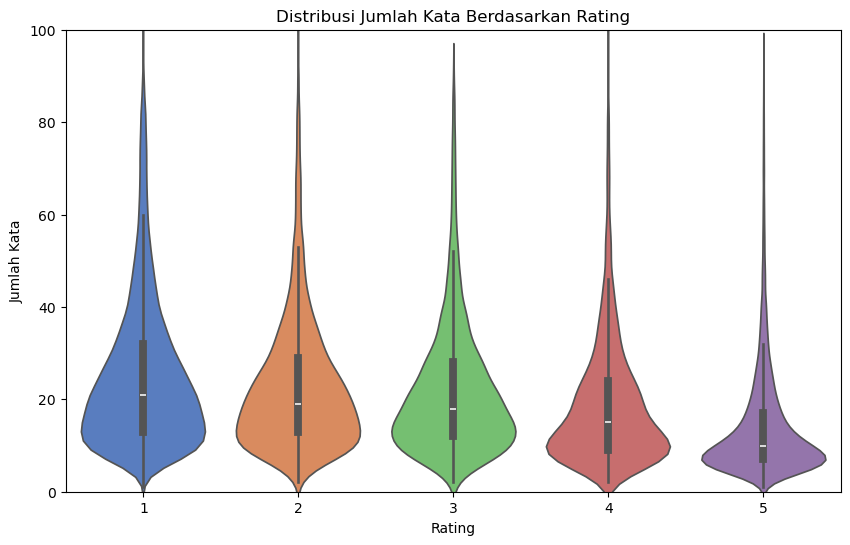

In [16]:
#word Count 
# Menghitung jumlah kata per ulasan
df['word_count'] = df['content'].apply(lambda x: len(str(x).split()))

plt.figure(figsize=(10, 6))
sns.violinplot(data=df, x='score', y='word_count', palette='muted')
plt.title('Distribusi Jumlah Kata Berdasarkan Rating')
plt.xlabel('Rating')
plt.ylabel('Jumlah Kata')
# Membatasi visualisasi agar outlier tidak merusak plot (misal maks 100 kata)
plt.ylim(0, 100) 
plt.show()

In [17]:
!pip install wordcloud matplotlib

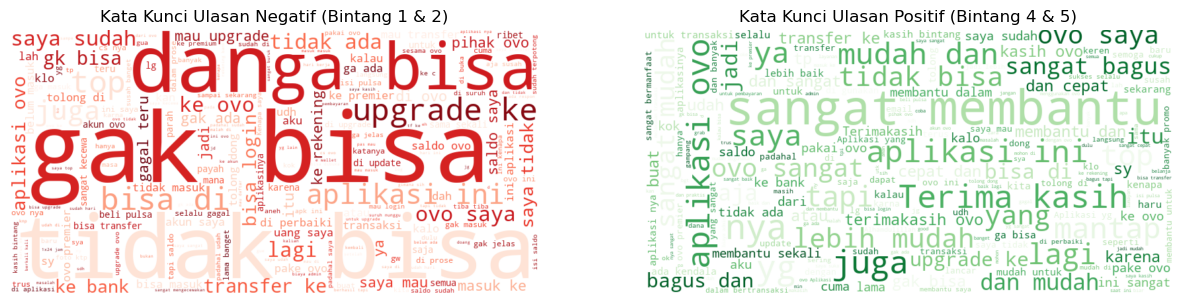

In [18]:
# 1. Pastikan library ini di-import di cell yang sama
import matplotlib.pyplot as plt
from wordcloud import WordCloud

# 2. Hapus nilai kosong (dropna) terlebih dahulu sebelum mengubahnya menjadi string
# Ini mencegah kata "nan" muncul di Word Cloud
negative_reviews = " ".join(review for review in df[df['score'] <= 2]['content'].dropna().astype(str))
positive_reviews = " ".join(review for review in df[df['score'] >= 4]['content'].dropna().astype(str))

# 3. Membuat WordCloud untuk ulasan negatif
wordcloud_neg = WordCloud(width=800, height=400, background_color='white', colormap='Reds').generate(negative_reviews)

# Konfigurasi ukuran visualisasi
plt.figure(figsize=(15, 6))

# Menampilkan WordCloud Negatif
plt.subplot(1, 2, 1)
plt.imshow(wordcloud_neg, interpolation='bilinear')
plt.title('Kata Kunci Ulasan Negatif (Bintang 1 & 2)')
plt.axis('off')

# 4. Membuat WordCloud untuk ulasan positif
wordcloud_pos = WordCloud(width=800, height=400, background_color='white', colormap='Greens').generate(positive_reviews)

# Menampilkan WordCloud Positif
plt.subplot(1, 2, 2)
plt.imshow(wordcloud_pos, interpolation='bilinear')
plt.title('Kata Kunci Ulasan Positif (Bintang 4 & 5)')
plt.axis('off')

# Tampilkan hasil akhir
plt.show()

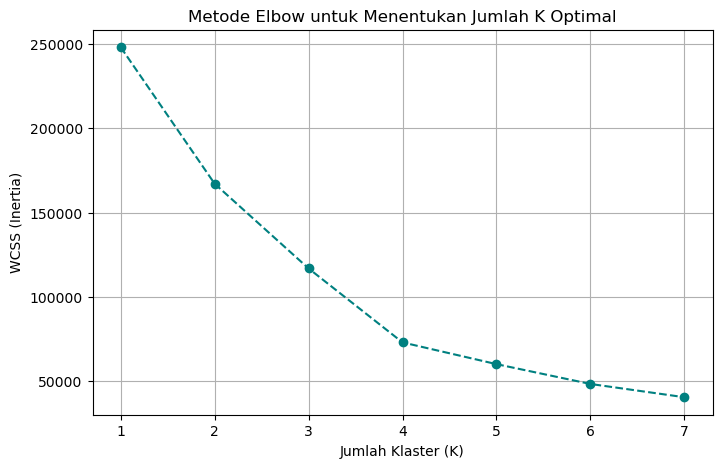

Ringkasan Statistik Profil Klaster:
         score  thumbsUpCount  review_length  jumlah_ulasan
cluster                                                    
0         1.21           1.96         154.14          55754
1         1.97         710.74         348.03             58
2         4.60           0.58          90.43          26901


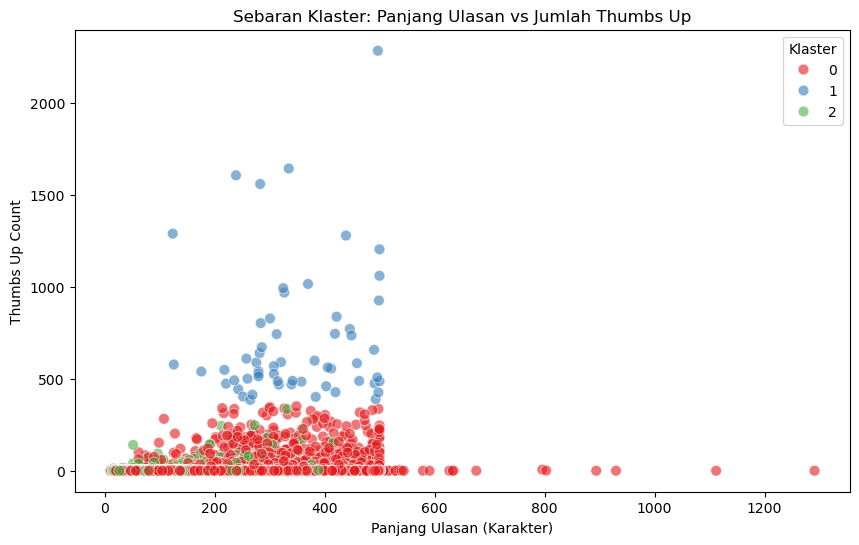

In [19]:
#Statistics Analysis 
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler

# 1. Persiapan Fitur
# Memastikan kolom panjang ulasan sudah ada
df['review_length'] = df['content'].astype(str).apply(len)

# Memilih fitur numerik utama
features = ['score', 'thumbsUpCount', 'review_length']
X = df[features].fillna(0)

# Standarisasi data sangat krusial dalam K-Means karena perbedaan skala 
# (misal: skor 1-5 vs panjang karakter 1-1000)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# 2. Evaluasi Jumlah Klaster Optimal (Metode Elbow)
wcss = []
K_range = range(1, 8)
for k in K_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(X_scaled)
    wcss.append(kmeans.inertia_)

plt.figure(figsize=(8, 5))
plt.plot(K_range, wcss, marker='o', linestyle='--', color='teal')
plt.title('Metode Elbow untuk Menentukan Jumlah K Optimal')
plt.xlabel('Jumlah Klaster (K)')
plt.ylabel('WCSS (Inertia)')
plt.grid(True)
plt.show()

# 3. Implementasi K-Means Final
# Asumsikan kurva mematah (elbow) berada di K=3
k_optimal = 3
kmeans_final = KMeans(n_clusters=k_optimal, random_state=42, n_init=10)
df['cluster'] = kmeans_final.fit_predict(X_scaled)

# 4. Profiling Hasil Statistik Klaster
cluster_summary = df.groupby('cluster')[features].mean().round(2)
cluster_summary['jumlah_ulasan'] = df.groupby('cluster').size()

print("Ringkasan Statistik Profil Klaster:")
print(cluster_summary)

# 5. Visualisasi Klastering (Scatter Plot 3D atau 2D)
plt.figure(figsize=(10, 6))
sns.scatterplot(data=df, x='review_length', y='thumbsUpCount', hue='cluster', 
                palette='Set1', s=60, alpha=0.6)
plt.title('Sebaran Klaster: Panjang Ulasan vs Jumlah Thumbs Up')
plt.xlabel('Panjang Ulasan (Karakter)')
plt.ylabel('Thumbs Up Count')
plt.legend(title='Klaster')
plt.show()

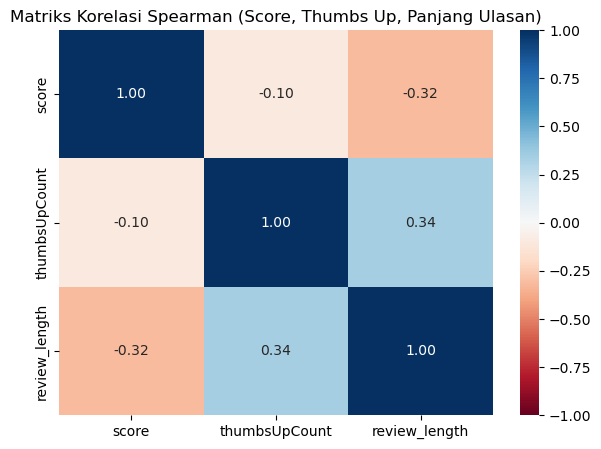

In [20]:
#Analisis Korelasi non-parametrik (Spearman)
import seaborn as sns
import matplotlib.pyplot as plt

# Memastikan panjang ulasan dihitung
df['review_length'] = df['content'].astype(str).apply(len)

# Menghitung matriks korelasi menggunakan metode Spearman
correlation_matrix = df[['score', 'thumbsUpCount', 'review_length']].corr(method='spearman')

plt.figure(figsize=(7, 5))
sns.heatmap(correlation_matrix, annot=True, cmap='RdBu', fmt=".2f", vmin=-1, vmax=1)
plt.title('Matriks Korelasi Spearman (Score, Thumbs Up, Panjang Ulasan)')
plt.show()

In [21]:
#Uji Hipotesis (Korelasi Spearman)
from scipy import stats

# Memisahkan kelompok: Ulasan Negatif (Bintang 1-2) vs Positif (Bintang 4-5)
thumbs_negative = df[df['score'] <= 2]['thumbsUpCount'].dropna()
thumbs_positive = df[df['score'] >= 4]['thumbsUpCount'].dropna()

# Melakukan Uji Mann-Whitney U (dua sisi)
stat, p_value = stats.mannwhitneyu(thumbs_negative, thumbs_positive, alternative='two-sided')

print(f"Statistik Uji: {stat}")
print(f"P-Value: {p_value}")

if p_value < 0.05:
    print("Kesimpulan: Terdapat perbedaan jumlah Thumbs Up yang signifikan secara statistik antara ulasan negatif dan positif.")
else:
    print("Kesimpulan: Tidak ada perbedaan signifikan dalam jumlah Thumbs Up antar kelompok ulasan.")

Statistik Uji: 679462407.0
P-Value: 1.059693659570414e-155
Kesimpulan: Terdapat perbedaan jumlah Thumbs Up yang signifikan secara statistik antara ulasan negatif dan positif.


/var/folders/n4/5f0j234x5m79703ndtqxkcr00000gn/T/ipykernel_2047/2088273954.py:20: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df_ngram, x='Frekuensi', y='N-Gram', palette='magma')


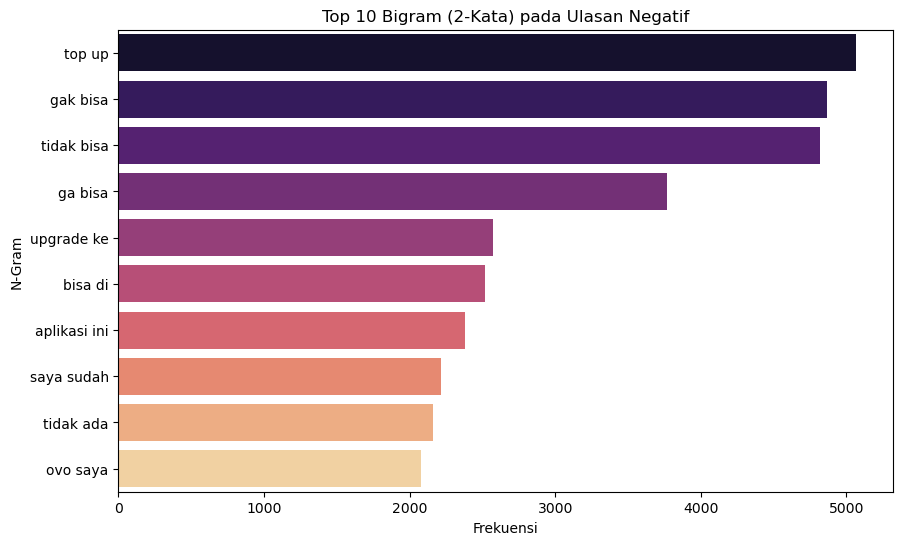

In [22]:
#N-Gram Analysis 
from sklearn.feature_extraction.text import CountVectorizer
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

def plot_top_ngrams(corpus, ngram_range=(2,2), top_n=10, title="Top N-Grams"):
    # Menginisialisasi CountVectorizer untuk Bigram (2 kata)
    vec = CountVectorizer(ngram_range=ngram_range, stop_words=None).fit(corpus)
    bag_of_words = vec.transform(corpus)
    
    # Menjumlahkan kemunculan setiap kombinasi kata
    sum_words = bag_of_words.sum(axis=0) 
    words_freq = [(word, sum_words[0, idx]) for word, idx in vec.vocabulary_.items()]
    words_freq = sorted(words_freq, key = lambda x: x[1], reverse=True)[:top_n]
    
    # Visualisasi
    df_ngram = pd.DataFrame(words_freq, columns=['N-Gram', 'Frekuensi'])
    plt.figure(figsize=(10, 6))
    sns.barplot(data=df_ngram, x='Frekuensi', y='N-Gram', palette='magma')
    plt.title(title)
    plt.show()

# Mengambil sampel ulasan negatif untuk dianalisis
ulasan_negatif = df[df['score'] <= 2]['content'].dropna().astype(str)

# Menampilkan 10 Bigram teratas dari ulasan negatif
plot_top_ngrams(ulasan_negatif, ngram_range=(2,2), top_n=10, title='Top 10 Bigram (2-Kata) pada Ulasan Negatif')